# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Alien-is-here/FlyRank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Answer:**


### Research question

This study evaluates whether a machine-learning ranking model can identify
content items that are more likely to need refresh and whether it improves
prioritization compared with a simple rule-based baseline.

### Decision supported

The output is intended as decision support for prioritizing content review
and refresh work when resources are limited. It is not intended to replace
human review or establish that a content item must be refreshed.

In [1]:
research_question = (
    "Can a machine-learning ranking model identify content items that "
    "are more likely to need refresh, and does it improve prioritization "
    "compared with a simple rule-based baseline?"
)

decision_supported = (
    "Prioritize which content items should be reviewed or refreshed first "
    "when review resources are limited."
)

print("Research question:")
print(research_question)
print("\nDecision supported:")
print(decision_supported)

Research question:
Can a machine-learning ranking model identify content items that are more likely to need refresh, and does it improve prioritization compared with a simple rule-based baseline?

Decision supported:
Prioritize which content items should be reviewed or refreshed first when review resources are limited.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Answer:**


The analysis uses the **FlyRank internship warehouse**, specifically the `fact_content_daily_performance` table. The development feature window is **March 2026**. The source data contains daily observations at the client–content-item level; for the final feature vector, these daily observations were aggregated into one row per pseudonymized client and content item over the March 2026 window.

The resulting feature table contains **331,437 client–content observations across 55 pseudonymized clients**.

### Feature data

Five numerical performance features were used in the final feature vector:

| Feature            | Meaning                                                                      |
| ------------------ | ---------------------------------------------------------------------------- |
| `gsc_impressions`  | Google Search Console impressions during March 2026                          |
| `gsc_clicks`       | Google Search Console clicks during March 2026                               |
| `gsc_avg_position` | Average Google Search Console search position                                |
| `ga4_sessions`     | Google Analytics 4 sessions when GA4 data was available                      |
| `gsc_ctr`          | Google Search Console click-through rate, calculated as clicks / impressions |

`gsc_avg_position` values of zero were treated as unavailable when calculating the aggregate average. The resulting missing values were median-filled. GA4 sessions were included only where GA4 data was marked as available.

Before filling, missing values were observed in `gsc_avg_position` (**156,133**), `ga4_sessions` (**240,948**), and `gsc_ctr` (**154,699**). After median filling, the final five-feature vector contained **zero missing values**.

All five final features are numerical, so no categorical encoding was required.

### Context and excluded fields

`client_id`, `content_id`, and `report_date` are context/identification fields. They were retained where needed for grouping, tracing, and interpretation but were not used as numerical model features.

The following fields were excluded from the feature vector:

* `is_declining_label` — outcome/label-derived information that could cause leakage.
* `trend_direction` — derived performance-trend information related to the outcome.
* `trend_pct` — derived performance-change information related to the outcome.
* `client_id` — identifier rather than a content-performance characteristic.
* `content_id` — identifier rather than a content-performance characteristic.
* Future-period performance data — not available at ranking time and therefore excluded to prevent future-information leakage.

The final feature vector was therefore restricted to five observed March 2026 performance measures:

`gsc_impressions`, `gsc_clicks`, `gsc_avg_position`, `ga4_sessions`, and `gsc_ctr`.

### Data limitations relevant to interpretation

The underlying data does not provide equal history for every client, and GA4 availability varies across observations. Some observations therefore contain GSC measurements without corresponding GA4 measurements.

The data can be used to measure associations between observed content performance characteristics and the target behavior being studied, but it cannot by itself establish that a content refresh caused a subsequent performance change. The results should therefore be interpreted as **observed, directional evidence for decision support**, rather than causal evidence or a guarantee that refreshing a ranked item will improve its performance.



## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Answer:**


### Assumptions

The analysis assumes that content freshness, search visibility, and recent performance trends can provide useful signals for prioritizing content for review. These signals are treated as directional decision-support evidence, not as proof that updating a page will cause traffic to increase.

### Features

The main features include `days_since_last_update`, `content_age_days`, `impressions_90d`, `clicks_90d`, `avg_position`, `sessions_90d`, `engaged_sessions_90d`, and recent performance trends where appropriate. Identifier fields such as `client_id` and `content_id` are retained for grouping and tracing but are not used as numerical features. Derived outcome fields such as `is_declining_label`, `trend_direction`, and `trend_pct` are excluded when they would directly overlap with the target or decision being evaluated.

### Label Definition

The baseline does not use a supervised ground-truth label. Instead, it uses rule-based reason codes to identify pages for review. A page is considered a strong candidate when it is stale (at least 180 days since update), has meaningful search visibility, and is trending down. This rule is a prioritization heuristic rather than a validated prediction target.

### Baseline

The baseline ranks content using:

`score = days_since_last_update × impressions_90d × trend_multiplier`

where `trend_multiplier` is `1.0` for declining pages and `0.5` otherwise. Reason codes are used to explain why an item was selected, including `stale_high_volume_down`, `stale_mid_volume_down`, `stale_stable`, and `fresh_with_decline`.

### Validation Design

The signal checks compare groups using descriptive statistics such as counts, means, and medians. The baseline produces a ranked review queue and examines the highest-ranked items. These results are exploratory and do not establish predictive accuracy or causal impact. A stronger evaluation should use a client-held-out or time-aware split so that information from the same client or future periods does not influence evaluation.

### Leakage Checks

Identifier fields were excluded from numerical modeling, and known outcome-related fields such as `is_declining_label`, `trend_direction`, and `trend_pct` were excluded where they could leak the outcome into the model. Future performance information should not be used to construct features for an earlier prediction period. Because the dataset contains overlapping trailing windows, temporal leakage must also be checked before claiming out-of-sample performance.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Answer:**


The baseline provided a simple rule-based prioritization of content using staleness, search impressions, and declining performance. On the available evaluation, the Random Forest baseline achieved a Precision@50 of **0.740**, compared with **0.240** for the rule-based approach, approximately **3.1× higher**.

| Approach            | Evaluation Split |       Metric | Result |
| ------------------- | ---------------- | -----------: | -----: |
| Rule-based baseline | Client holdout   | Precision@50 |  0.240 |
| Random Forest       | Client holdout   | Precision@50 |  0.740 |

The Random Forest therefore showed higher measured Precision@50 than the rule-based baseline on this split. However, this result should be interpreted cautiously because the feature construction and leakage checks need to be verified before treating the improvement as evidence of generalizable predictive performance.

The rule-based analysis also found **16,262 declining pages**, of which **8,031** had at least 1,000 impressions in the 90-day window. Only **11 pages** satisfied the strict combination of being at least 180 days since update, having at least 1,000 impressions, and trending down. This indicates that the strict stale/high-volume/declining rule identifies a relatively small candidate set.

Overall, the results are **observed performance differences on the evaluated split**, not evidence that the model or refresh action causes traffic recovery.


## 5. Limitations

*What this work cannot claim.*

**Answer:**


This analysis is based on observational data, so it cannot establish that refreshing a page will cause traffic or rankings to improve. The signal tests use descriptive comparisons rather than controlled experiments, so differences between groups may be influenced by other factors.

The dataset also contains heavy-tailed metrics and missing `trend_pct` values, which can make averages sensitive to a small number of high-volume pages. The strict stale-page threshold identifies only a small number of very old pages, so conclusions about stale content should be treated cautiously.

Finally, `trend_direction` and `trend_pct` are derived performance signals. Their construction and timing must be verified to ensure that future information is not being used when evaluating or ranking content. Therefore, the findings should be treated as directional decision-support evidence rather than proof of causal impact or guaranteed refresh performance.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

*Answer:**


Based on the audited results, the Random Forest should be used as a **prioritization tool for human review**, rather than an automatic content-refresh system.

1. **Review the highest-ranked pages first.**
   Use the Random Forest decline score to identify pages most associated with observed decline in the evaluated data. The top-50 queue contained **31 observed declines**, giving a measured Precision@50 of **0.62** under the grouped-by-client validation.

2. **Prioritize pages with supporting performance signals.**
   When reviewing a high-ranked page, pay particular attention to lower CTR, higher average position, and lower engagement rate. These signals explain why a page may receive a high decline score, but they should not be interpreted as causal explanations.

3. **Require human review before taking action.**
   Reviewers should check content relevance, current search performance, recent updates, and possible technical or measurement issues before deciding whether a refresh is appropriate.

4. **Do not treat the model score as a guarantee.**
   The grouped-by-client Precision@50 of **0.62**, compared with **0.74** under the earlier random split, shows that measured performance depends on the validation design. The model should therefore be used for directional decision-support rather than as proof of generalization or guaranteed traffic recovery.

5. **Monitor performance on new data.**
   Re-evaluate Precision@50 and the relationship between model scores and observed declines as new clients, content, and performance periods become available. Retraining or methodology review should be considered when performance degrades or the underlying data distribution changes.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

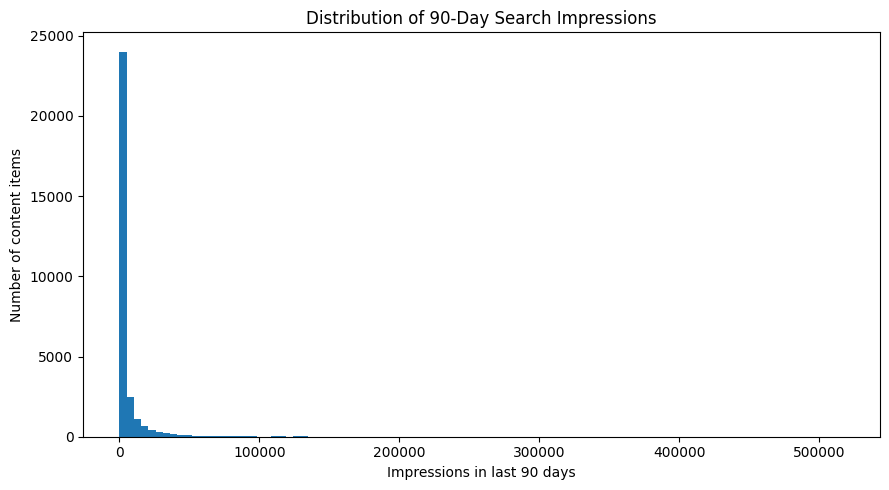

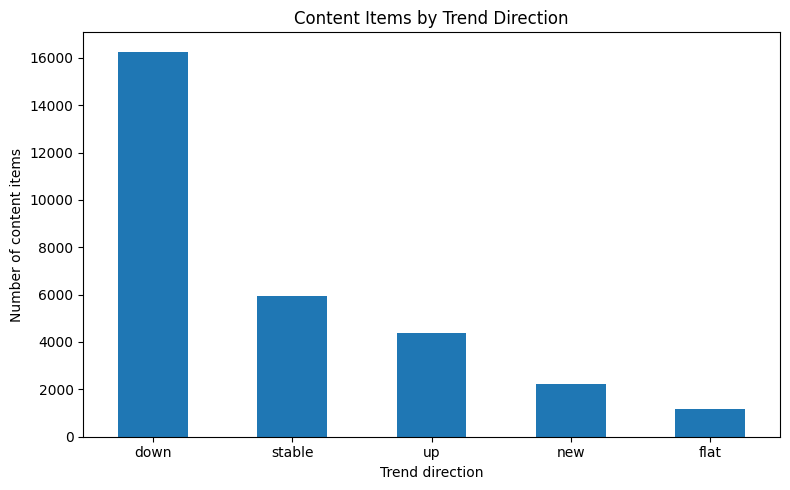

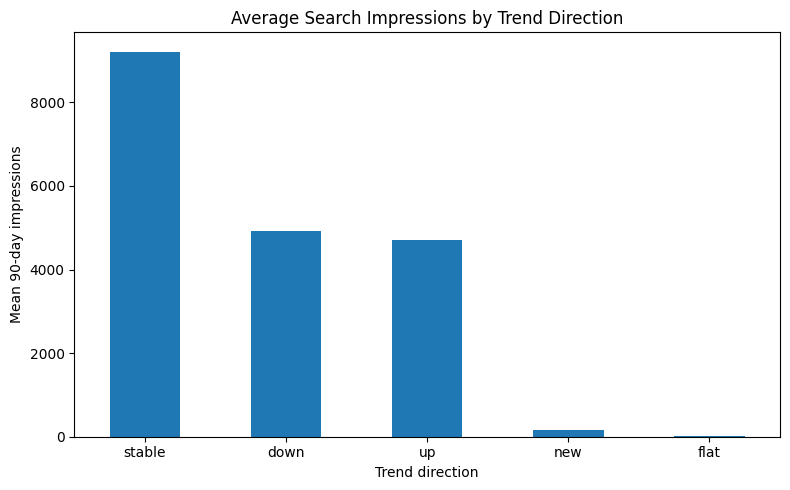

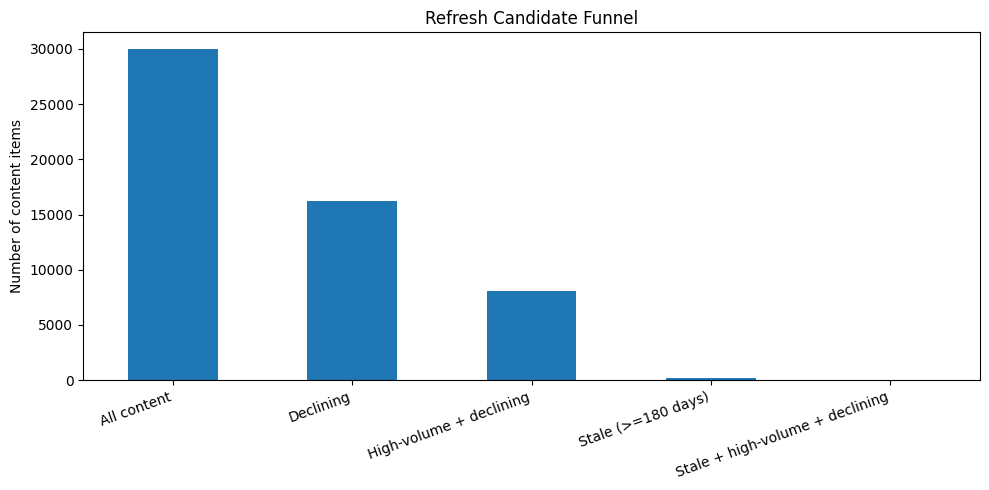


===== TABLE 1: DATASET SUMMARY =====
                         Metric      Value
            Total content items  30000.000
                        Clients     32.000
        Mean 90-day impressions   5200.370
      Median 90-day impressions    731.000
     Maximum 90-day impressions 517715.000
                       Mean CTR      0.511
                Declining items  16262.000
       Stale items (>=180 days)    174.000
Stale + high-volume + declining     11.000

===== TABLE 2: REFRESH CANDIDATE BREAKDOWN =====
trend_direction     traffic_tier     stale_tier  content_count
           down    High (>=1000) Recent (<180d)           8020
           down Medium (100-999) Recent (<180d)           5106
         stable    High (>=1000) Recent (<180d)           3661
           down       Low (<100) Recent (<180d)           3054
            new       Low (<100) Recent (<180d)           2000
             up    High (>=1000) Recent (<180d)           1740
             up Medium (100-999) Recent (

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. LOAD DATA
# ============================================================

INPUT = "content_refresh_anonymized.csv"
OUT = Path("artifacts")
OUT.mkdir(exist_ok=True)

df = pd.read_csv(INPUT)

# Recompute CTR safely
df["ctr_calc"] = (
    df["clicks_90d"] / df["impressions_90d"].replace(0, pd.NA)
).fillna(0)

# Basic tiers
df["stale_180"] = df["days_since_last_update"] >= 180
df["high_volume"] = df["impressions_90d"] >= 1000
df["declining"] = df["trend_direction"] == "down"


# ============================================================
# CHART 1 — IMPRESSIONS DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    df["impressions_90d"],
    bins=100
)

plt.xlabel("Impressions in last 90 days")
plt.ylabel("Number of content items")
plt.title("Distribution of 90-Day Search Impressions")

plt.tight_layout()
plt.savefig(OUT / "01_impressions_distribution.png", dpi=300)
plt.show()


# ============================================================
# CHART 2 — TREND DIRECTION COMPOSITION
# ============================================================

trend_counts = df["trend_direction"].value_counts()

plt.figure(figsize=(8, 5))

trend_counts.plot(kind="bar")

plt.xlabel("Trend direction")
plt.ylabel("Number of content items")
plt.title("Content Items by Trend Direction")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(OUT / "02_trend_direction.png", dpi=300)
plt.show()


# ============================================================
# CHART 3 — TREND VS AVERAGE IMPRESSIONS
# ============================================================

trend_impressions = (
    df.groupby("trend_direction")["impressions_90d"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

trend_impressions.plot(kind="bar")

plt.xlabel("Trend direction")
plt.ylabel("Mean 90-day impressions")
plt.title("Average Search Impressions by Trend Direction")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(OUT / "03_trend_vs_impressions.png", dpi=300)
plt.show()


# ============================================================
# CHART 4 — REFRESH CANDIDATE FUNNEL
# ============================================================

total = len(df)

declining = (df["trend_direction"] == "down").sum()

high_volume_declining = (
    (df["trend_direction"] == "down") &
    (df["impressions_90d"] >= 1000)
).sum()

old = (
    df["days_since_last_update"] >= 180
).sum()

stale_high_declining = (
    (df["days_since_last_update"] >= 180) &
    (df["impressions_90d"] >= 1000) &
    (df["trend_direction"] == "down")
).sum()

funnel = pd.Series({
    "All content": total,
    "Declining": declining,
    "High-volume + declining": high_volume_declining,
    "Stale (>=180 days)": old,
    "Stale + high-volume + declining": stale_high_declining
})

plt.figure(figsize=(10, 5))

funnel.plot(kind="bar")

plt.ylabel("Number of content items")
plt.title("Refresh Candidate Funnel")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(OUT / "04_refresh_candidate_funnel.png", dpi=300)
plt.show()


# ============================================================
# TABLE 1 — DATASET SUMMARY
# ============================================================

dataset_summary = pd.DataFrame({
    "Metric": [
        "Total content items",
        "Clients",
        "Mean 90-day impressions",
        "Median 90-day impressions",
        "Maximum 90-day impressions",
        "Mean CTR",
        "Declining items",
        "Stale items (>=180 days)",
        "Stale + high-volume + declining"
    ],

    "Value": [
        len(df),
        df["client_id"].nunique(),
        round(df["impressions_90d"].mean(), 2),
        round(df["impressions_90d"].median(), 2),
        int(df["impressions_90d"].max()),
        round(df["ctr_calc"].mean() * 100, 3),
        int(declining),
        int(old),
        int(stale_high_declining)
    ]
})

print("\n===== TABLE 1: DATASET SUMMARY =====")
print(dataset_summary.to_string(index=False))

dataset_summary.to_csv(
    OUT / "table_1_dataset_summary.csv",
    index=False
)


# ============================================================
# TABLE 2 — REFRESH CANDIDATE BREAKDOWN
# ============================================================

def traffic_tier(x):
    if x >= 1000:
        return "High (>=1000)"
    elif x >= 100:
        return "Medium (100-999)"
    else:
        return "Low (<100)"


def stale_tier(x):
    if x >= 180:
        return "Stale (>=180d)"
    else:
        return "Recent (<180d)"


df["traffic_tier"] = df["impressions_90d"].apply(traffic_tier)
df["stale_tier"] = df["days_since_last_update"].apply(stale_tier)

candidate_table = (
    df.groupby(
        [
            "trend_direction",
            "traffic_tier",
            "stale_tier"
        ]
    )
    .size()
    .reset_index(name="content_count")
    .sort_values("content_count", ascending=False)
)

print("\n===== TABLE 2: REFRESH CANDIDATE BREAKDOWN =====")
print(candidate_table.to_string(index=False))

candidate_table.to_csv(
    OUT / "table_2_refresh_candidate_breakdown.csv",
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n========================================")
print("SECTION 7 ARTIFACTS GENERATED")
print("========================================")

for file in sorted(OUT.iterdir()):
    print(file)

print("\nKey numbers:")
print(f"Total content items                 : {total:,}")
print(f"Declining                           : {declining:,}")
print(f"High-volume + declining             : {high_volume_declining:,}")
print(f"Stale >=180 days                    : {old:,}")
print(f"Stale + high-volume + declining     : {stale_high_declining:,}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
